In [45]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
New_data=pd.read_csv("final_data_LOO.csv")
New_data.head()

,Unnamed: 0,day,data_temperature_mean,data_temperature_std,data_humidity_mean,data_humidity_std,data_pm2_5_mean,data_pm2_5_std,data_pm2_5_min,data_pm2_5_max,data_voc_mean,data_voc_std,data_voc_min,data_voc_max,data_co2_mean,data_co2_std,data_co2_min,Target
0,0,0,28.838333,0.009832,68.393333,0.081650,198.666667,2.503331,195,202,1.112167,0.005154,1.104,1.118,377.166667,10.962056,368,No Activity
1,1,0,28.841667,0.004082,68.393333,0.081650,197.833333,2.786874,195,202,1.114500,0.003674,1.108,1.118,372.833333,4.020779,368,No Activity
2,2,0,28.841667,0.004082,68.376667,0.098319,196.333333,2.503331,193,200,1.118667,0.007257,1.114,1.133,371.666667,2.658320,368,No Activity
3,3,0,28.845000,0.008367,68.328333,0.118392,197.000000,2.607681,193,200,1.122333,0.010053,1.114,1.137,374.333333,8.801515,368,No Activity
4,4,0,28.851667,0.016021,68.263333,0.137210,196.833333,2.401388,193,199,1.125333,0.011130,1.114,1.137,378.166667,10.361789,370,No Activity


In [46]:
New_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2777 entries, 0 to 2776
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             2777 non-null   int64  
 1   day                    2777 non-null   int64  
 2   data_temperature_mean  2777 non-null   float64
 3   data_temperature_std   2777 non-null   float64
 4   data_humidity_mean     2777 non-null   float64
 5   data_humidity_std      2777 non-null   float64
 6   data_pm2_5_mean        2777 non-null   float64
 7   data_pm2_5_std         2777 non-null   float64
 8   data_pm2_5_min         2777 non-null   int64  
 9   data_pm2_5_max         2777 non-null   int64  
 10  data_voc_mean          2777 non-null   float64
 11  data_voc_std           2777 non-null   float64
 12  data_voc_min           2777 non-null   float64
 13  data_voc_max           2777 non-null   float64
 14  data_co2_mean          2777 non-null   float64
 15  data

In [47]:
New_data1=New_data.drop(['Unnamed: 0'],axis=1)

In [48]:
New_data1['Target'].value_counts()

,count
Target,
Boil,769
No Activity,615
Curry,604
Fry,335
Reheat,267
Boil(Pressure Cooker),187


In [49]:
New_data2=New_data1.drop(['data_co2_mean','data_co2_std','data_co2_min'],axis=1)
New_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2777 entries, 0 to 2776
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   day                    2777 non-null   int64  
 1   data_temperature_mean  2777 non-null   float64
 2   data_temperature_std   2777 non-null   float64
 3   data_humidity_mean     2777 non-null   float64
 4   data_humidity_std      2777 non-null   float64
 5   data_pm2_5_mean        2777 non-null   float64
 6   data_pm2_5_std         2777 non-null   float64
 7   data_pm2_5_min         2777 non-null   int64  
 8   data_pm2_5_max         2777 non-null   int64  
 9   data_voc_mean          2777 non-null   float64
 10  data_voc_std           2777 non-null   float64
 11  data_voc_min           2777 non-null   float64
 12  data_voc_max           2777 non-null   float64
 13  Target                 2777 non-null   object 
dtypes: float64(10), int64(3), object(1)
memory usage: 303.9+

In [50]:
X =New_data2.drop('Target',axis=1)
y=New_data2['Target']

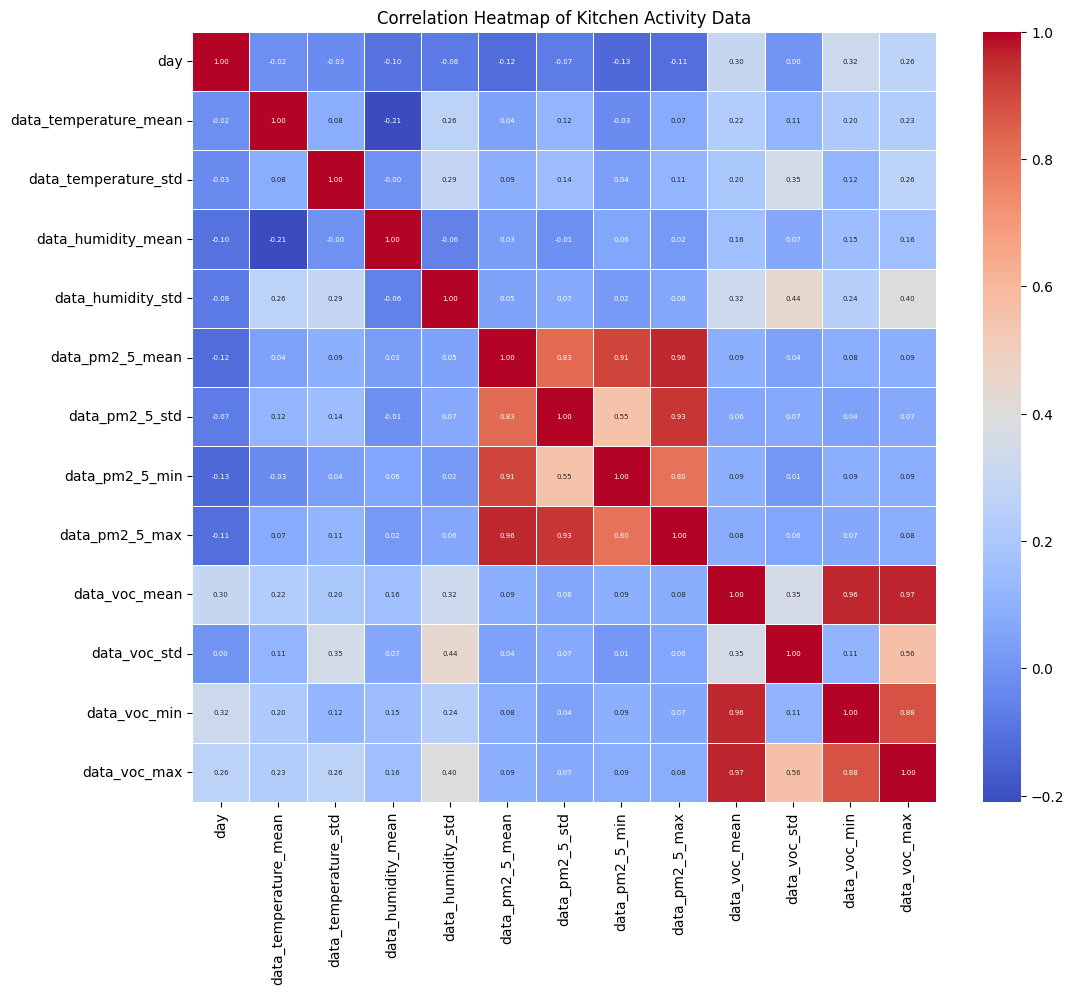

In [51]:
corr_matrix = X.corr()
plt.figure(figsize=(12, 10)) # Optional: Adjusts the figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 5})
plt.title("Correlation Heatmap of Kitchen Activity Data") # Optional: Add a title
plt.show() # Display the plot


/tmp/ipykernel_12418/2278154754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, data=New_data2,palette='Set2')


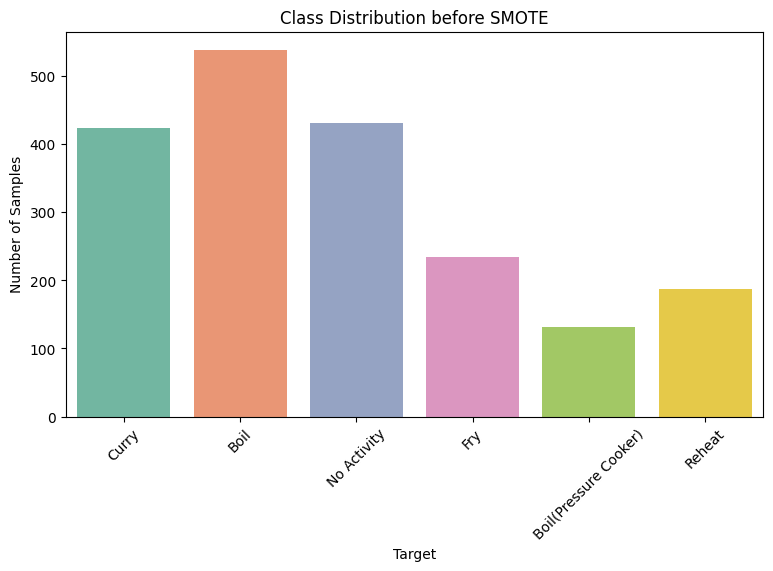

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42, stratify=y)

plt.figure(figsize=(9, 5))
sns.countplot(x=y_train, data=New_data2,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution before SMOTE')
plt.ylabel('Number of Samples')
plt.show()


/tmp/ipykernel_12418/1519018407.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= y_train_resampled, data=New_data2,palette='Set2')


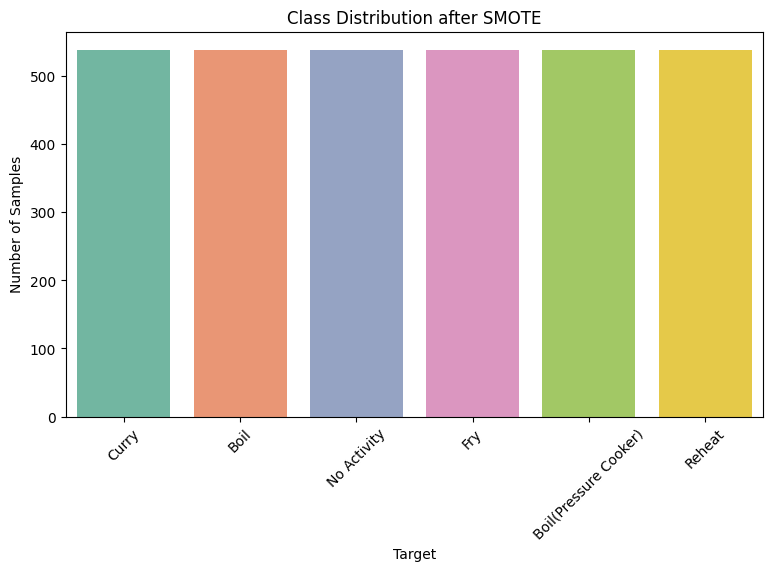

In [53]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)


plt.figure(figsize=(9, 5))
sns.countplot(x= y_train_resampled, data=New_data2,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution after SMOTE')
plt.ylabel('Number of Samples')
plt.show()

In [54]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

                       precision    recall  f1-score   support

                 Boil       0.87      0.81      0.84       231
Boil(Pressure Cooker)       0.85      0.91      0.88        56
                Curry       0.81      0.80      0.81       181
                  Fry       0.79      0.85      0.82       101
          No Activity       0.90      0.93      0.91       185
               Reheat       0.80      0.82      0.81        80

             accuracy                           0.85       834
            macro avg       0.84      0.85      0.84       834
         weighted avg       0.85      0.85      0.85       834



In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print('-------------- Random Forest without Scaled Data -------------\n')
print(classification_report(y_test, y_pred))

-------------- Random Forest without Scaled Data -------------

                       precision    recall  f1-score   support

                 Boil       0.93      0.92      0.93       231
Boil(Pressure Cooker)       0.89      0.96      0.92        56
                Curry       0.92      0.88      0.90       181
                  Fry       0.83      0.93      0.88       101
          No Activity       0.95      0.95      0.95       185
               Reheat       0.97      0.91      0.94        80

             accuracy                           0.92       834
            macro avg       0.92      0.93      0.92       834
         weighted avg       0.92      0.92      0.92       834



In [56]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 3. Configure K-fold cross-validation
# n_splits (k) is set to 5. shuffle=True ensures random distribution of data.
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and get scores
# 'cv' parameter takes the cross-validation iterator
scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=k_folds)

# 5. Print the results
print("Cross Validation Scores:", scores)
print(f"Average CV Score: {np.mean(scores):.4f}")
print("Number of CV Scores used in Average:", len(scores))


Cross Validation Scores: [0.94427245 0.94117647 0.95510836 0.95193798 0.93488372]
Average CV Score: 0.9455
Number of CV Scores used in Average: 5


In [57]:
import pickle

with open('kitchen_activity_CO2.pkl', 'wb') as file:
    pickle.dump(model, file)

In [58]:
y_test

,Target
1453,No Activity
2661,Fry
1259,Boil
1971,Boil
1901,Curry
...,...
634,Boil
1664,Curry
1590,Reheat
1333,No Activity


In [59]:
import lime
import lime.lime_tabular

# 1. Setup the explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns.tolist(),
    # FIX: Ensure classes are sorted (e.g., [0, 1]) so LIME doesn't flip the labels
    class_names=[str(c) for c in sorted(y_train_resampled.unique())],
    mode='classification'
)

idx = 2

# 2. Explain the instance
exp = explainer.explain_instance(
    X_test.iloc[idx].values,
    model.predict_proba, # Random Forest handles raw NumPy arrays perfectly here
    top_labels=1,        # Set to 1 if binary classification to see the positive class explanation
    num_features=10
)

# 3. Visualize the result
exp.show_in_notebook(show_table=True)

ModuleNotFoundError: No module named 'lime'

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)

model = XGBClassifier()
model.fit(X_train_resampled, y_train_encoded)

# Evaluate the model
y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded) # Convert back to original labels
print('   -------------- XGBoost without Scaled Data -------------\n')
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 3. Configure K-fold cross-validation
# n_splits (k) is set to 5. shuffle=True ensures random distribution of data.
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and get scores
# 'cv' parameter takes the cross-validation iterator
scores = cross_val_score(model, X_train_resampled, y_train_encoded, cv=k_folds)

# 5. Print the results
print("Cross Validation Scores:", scores)
print(f"Average CV Score: {np.mean(scores):.4f}")
print("Number of CV Scores used in Average:", len(scores))


In [ ]:
import lime
import lime.lime_tabular

# 1. Setup the explainer safely
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns.tolist(), # Convert to list explicitly
    class_names=[str(c) for c in sorted(y_train_resampled.unique())],
    mode='classification'
)

idx = 4

# 2. Define a wrapper function if XGBoost complains about feature names
# This ensures XGBoost always receives a DataFrame with the correct columns
def predict_fn(x):
    import pandas as pd
    # Convert LIME's internal numpy array back to a DataFrame with original columns
    df = pd.DataFrame(x, columns=X_train_resampled.columns)
    return model.predict_proba(df)

# 3. Explain the instance
exp = explainer.explain_instance(
    data_row=X_test.iloc[idx].values, # LIME needs a 1D array here
    predict_fn=predict_fn,             # Use our safe wrapper instead of model.predict_proba
    top_labels=2,
    num_features=10
)

# 4. Visualize the result
exp.show_in_notebook(show_table=True)